# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [12]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 435.7 kB/s eta 0:00:30
     --------------------------------------- 0.1/12.8 MB 544.7 kB/s eta 0:00:24
     --------------------------------------- 0.1/12.8 MB 581.0 kB/s eta 0:00:22
     --------------------------------------- 0.1/12.8 MB 581.0 kB/s eta 0:00:22
     --------------------------------------- 0.2/12.8 MB 701.4 kB/s eta 0:00:19
      -------------------------------------- 0.2/12.8 MB 692.4 kB/s eta 0:00:19
     - -------------------------------------- 0.4/12.8 MB 1.1 MB/s eta 0:00:12
     - -------------------------------------- 0.5/12.8 MB 1.4 MB/s eta 0:00:09
     -- ------------------------------------- 0.7/12.8 MB 1.5 MB/s eta 0:00:08
     -- ------------------------------------- 0.8/12.8 MB 1.7 MB/s eta 0:00:08
     -- ------------------------------------- 0.8/12.8 MB 1.7 MB/s eta 0:00:08
     --- ------------------------------------ 1.1/12.

## Importing the necessary libraries

In [14]:
# Import essential libraries for data manipulation and analysis

# Numerical computing and data manipulation
import numpy as np  # For numerical operations and array handling
import pandas as pd  # For handling dataframes and tabular data

# Text processing and visualization
import re  # For regular expression operations (text cleaning)
import string  # For string-level operations like punctuation removal

# NLP tools and preprocessing utilities
import nltk  # Natural Language Toolkit for various NLP tasks
import spacy  # For advanced NLP tasks (not used here but good to keep if needed)

# Feature extraction for n-grams
from sklearn.feature_extraction.text import CountVectorizer  # For creating bag-of-words models and n-grams

# Visualization libraries
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns  # For statistical visualizations
from wordcloud import WordCloud  # To generate word clouds from text

# NLTK specific preprocessing tools
from nltk import word_tokenize, pos_tag  # Tokenization and Part-of-Speech tagging
from nltk.corpus import stopwords  # Common stopwords in English
from nltk.stem import WordNetLemmatizer  # Lemmatization of words

In [15]:
# Download NLTK Resources (One-time setup)
nltk.download('punkt')  # Tokenizer models
nltk.download('averaged_perceptron_tagger')  # POS tagger
nltk.download('wordnet')  # WordNet lexicon for lemmatization
nltk.download('stopwords')  # List of common stopwords

# Optional and less commonly used resources (included for completeness)
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saumy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\saumy\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saumy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saumy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\saumy\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saumy\AppData\Roaming\nltk_d

True

In [16]:
# Optional: to enable GPU support for spaCy (if you have a compatible GPU)
spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [17]:
## Change the display properties of pandas to max
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [19]:
# Import the first file - True.csv
True_df = pd.read_csv("True.csv")
# Import the second file - Fake.csv
Fake_df = pd.read_csv("Fake.csv")

## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [22]:
# Inspect the DataFrame with True News to understand the given data
# Check the shape of True_df DataFrame
print("True News Data Shape:", True_df.shape)

# Display first 5 rows from True news data
print("\nSample of True News Data:")
print(True_df.head())

# Check column names and data types
print("\nTrue News Columns and Types:")
print(True_df.dtypes)

True News Data Shape: (21417, 3)

Sample of True News Data:
                                                                   title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [23]:
# Inspect the DataFrame with Fake News to understand the given data
# Check the shape of Fake_df DataFrame
print("Fake News Data Shape:", Fake_df.shape)

# Display first 5 rows from Fake news data
print("\nSample of Fake News Data:")
print(Fake_df.head())

# Check column names and data types
print("\nFake News Columns and Types:")
print(Fake_df.dtypes)

Fake News Data Shape: (23523, 3)

Sample of Fake News Data:
                                                                                        title  \
0              Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing   
1                        Drunk Bragging Trump Staffer Started Russian Collusion Investigation   
2   Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’   
3               Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES)   
4                       Pope Francis Just Called Out Donald Trump During His Christmas Speech   

                                                                                                                                                                                                                                                                                                                                                                     

In [24]:
# Print the column details for True News DataFrame
print("True News DataFrame Info:\n")
print(True_df.info())

True News DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB
None


In [25]:
# Print the column details for Fake News Dataframe
print("Fake News DataFrame Info:\n")
print(Fake_df.info())

Fake News DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB
None


In [26]:
# Print the column names of both DataFrames
# Print column names for True News
print("Column Names in True News DataFrame:", list(True_df.columns))

# Print column names for Fake News
print("Column Names in Fake News DataFrame:", list(Fake_df.columns))

Column Names in True News DataFrame: ['title', 'text', 'date']
Column Names in Fake News DataFrame: ['title', 'text', 'date']


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [28]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
True_df['news_label'] = 1  # 1 indicates true news
# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
Fake_df['news_label'] = 0  # 0 indicates fake news

# Let's check a few rows to confirm
print("True News Sample with Label:\n", True_df[['title', 'news_label']].head())
print("\nFake News Sample with Label:\n", Fake_df[['title', 'news_label']].head())

True News Sample with Label:
                                                                    title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

   news_label  
0           1  
1           1  
2           1  
3           1  
4           1  

Fake News Sample with Label:
                                                                                         title  \
0              Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing   
1                        Drunk Bragging Trump Staffer Started Russian Collusion Investigation   
2   Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’  

### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [30]:
# Combine the true and fake news DataFrames into a single DataFrame
combined_news_df = pd.concat([True_df, Fake_df], ignore_index=True)

In [31]:
# Display the first 5 rows of the combined DataFrame to verify the result
print("\nSample Rows from Combined DataFrame:")
print(combined_news_df.head(5))

# Display the shape of the combined DataFrame to verify the merge
print("Combined DataFrame Shape:", combined_news_df.shape)


Sample Rows from Combined DataFrame:
                                                                   title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [33]:
# Check Presence of Null Values
print("Null Values in Each Column:")
print(combined_news_df.isnull().sum())

Null Values in Each Column:
title         21
text          21
date          42
news_label     0
dtype: int64


In [34]:
# Handle Rows with Null Values
# Since title and text are crucial for classification, we'll drop rows with any nulls in these
# Also, date may not be used directly, so priority is on title and text
# Drop rows where either 'title' or 'text' is missing
combined_news_df.dropna(subset=['title', 'text'], inplace=True)

# Check the new shape and confirm nulls are handled
print("Shape after dropping rows with nulls in 'title' or 'text':", combined_news_df.shape)
print("\nRemaining null values:\n", combined_news_df.isnull().sum())

Shape after dropping rows with nulls in 'title' or 'text': (44919, 4)

Remaining null values:
 title          0
text           0
date          21
news_label     0
dtype: int64


### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [36]:
# Create a copy of the original combined DataFrame for modeling
combined_news_df_for_model = combined_news_df.copy()

In [37]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
# Combine 'title' and 'text' into a single column called 'news_text'
combined_news_df_for_model['news_text'] = combined_news_df_for_model['title'] + " " + combined_news_df_for_model['text']

# Drop the irrelevant columns from the DataFrame as they are no longer needed
# Drop the now redundant columns
combined_news_df_for_model.drop(columns=['title', 'text', 'date'], inplace=True)

# Display the first 5 rows of the updated DataFrame to check the result
print("Shape of modeling DataFrame:", combined_news_df_for_model.shape)
print("Sample of modeling DataFrame:")
print(combined_news_df_for_model.head())

Shape of modeling DataFrame: (44919, 2)
Sample of modeling DataFrame:
   news_label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [41]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed
df_clean = pd.DataFrame()

# Add 'news_label' column to the new dataframe for topic identification
df_clean['news_label'] = combined_news_df_for_model['news_label']

# Create empty columns for cleaned and lemmatized text
df_clean['cleaned_text'] = ""
df_clean['lemmatized_text'] = ""

# Preview structure
print("df_clean structure:\n")
print(df_clean.head())

df_clean structure:

   news_label cleaned_text lemmatized_text
0           1                             
1           1                             
2           1                             
3           1                             
4           1                             


#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [43]:
# Write the function here to clean the text and remove all the unnecessary elements
def clean_text(text):
    # Convert to lower case
    text = text.lower()
    # Remove text in square brackets
    text = re.sub(r'\[.*?\]', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove words with numbers
    text = re.sub(r'\w*\d\w*', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [45]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame
df_clean['cleaned_text'] = combined_news_df_for_model['news_text'].apply(clean_text)

In [46]:
# Preview to confirm cleaned text is stored properly
print("Sample Cleaned Text:\n")
print(df_clean[['news_label', 'cleaned_text']].head(3))

Sample Cleaned Text:

   news_label  \
0           1   
1           1   
2           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [49]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags
# Initialize the lemmatizer and stopwords set
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to lemmatize text and retain only nouns (NN, NNS)
def lemmatize_nouns(text):
    tokens = word_tokenize(text)             # Tokenize the input text
    pos_tags = pos_tag(tokens)               # Tag each token with its part of speech
    
    # Filter for nouns only, convert to lowercase, remove stopwords, and lemmatize
    lemmatized_nouns = [
        lemmatizer.lemmatize(word.lower(), pos='n')
        for word, tag in pos_tags
        if tag in ['NN', 'NNS'] and word.lower() not in stop_words
    ]
    return ' '.join(lemmatized_nouns)        # Join the processed words back into a string

#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [51]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
df_clean['lemmatized_text'] = df_clean['cleaned_text'].apply(lemmatize_nouns)

In [52]:
# Preview result
print("\nSample after Lemmatization:\n")
df_clean[['news_label', 'cleaned_text', 'lemmatized_text']].head()


Sample after Lemmatization:



news_label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

### Save the Cleaned data as a csv file (Recommended)

In [54]:
## Recommended to perform the below steps to save time while rerunning the code
# 1. Save the cleaned data to CSV 
df_clean.to_csv("clean_df.csv", index=False)

In [55]:
# 2. Reload the saved CSV
df_clean = pd.read_csv("clean_df.csv")

In [56]:
# Check the first few rows of the DataFrame
print(df_clean.head())

   news_label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [57]:
# Check the dimensions of the DataFrame
# Check DataFrame shape
print("\nShape of df_clean:", df_clean.shape)


Shape of df_clean: (44919, 3)


In [58]:
# Check the number of non-null entries and data types of each column
# Check column info
print("\nDataFrame info:")
print(df_clean.info())


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44919 entries, 0 to 44918
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   news_label       44919 non-null  int64 
 1   cleaned_text     44910 non-null  object
 2   lemmatized_text  44910 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB
None


In [59]:
# Drop Nulls (Safe Step Before Splitting)
df_clean = df_clean.dropna(subset=['cleaned_text', 'lemmatized_text']).reset_index(drop=True)
print("New shape after dropping nulls:", df_clean.shape)

New shape after dropping nulls: (44910, 3)


In [60]:
# Check Presence of Null Values after Droping
print("Null Values in Each Column after Droping NA:")
print(df_clean.isnull().sum())

Null Values in Each Column after Droping NA:
news_label         0
cleaned_text       0
lemmatized_text    0
dtype: int64


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [62]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
from sklearn.model_selection import train_test_split
# Split the dataset into training and validation sets (70% train, 30% val)
X_train, X_val, y_train, y_val = train_test_split(
    df_clean[['cleaned_text', 'lemmatized_text']],  # Use both text columns as features
    df_clean['news_label'],                         # Target variable: 1 for true, 0 for fake
    test_size=0.3,                                  # 30% of data for validation
    random_state=9,                                 # Ensure reproducibility of the split
    stratify=df_clean['news_label']                 # Maintain label distribution in both splits
)

In [63]:
# Check the shapes
print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

Training set size: 31437
Validation set size: 13473
y_train shape: (31437,)
y_val shape: (13473,)


## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [67]:
# Add a new column to calculate the character length of cleaned news text
X_train['cleaned_text_len'] = X_train['cleaned_text'].apply(lambda x: len(str(x)))

# Add a new column to calculate the character length of lemmatized news text with POS tags removed
X_train['lemmatized_text_len'] = X_train['lemmatized_text'].apply(lambda x: len(str(x)))

##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

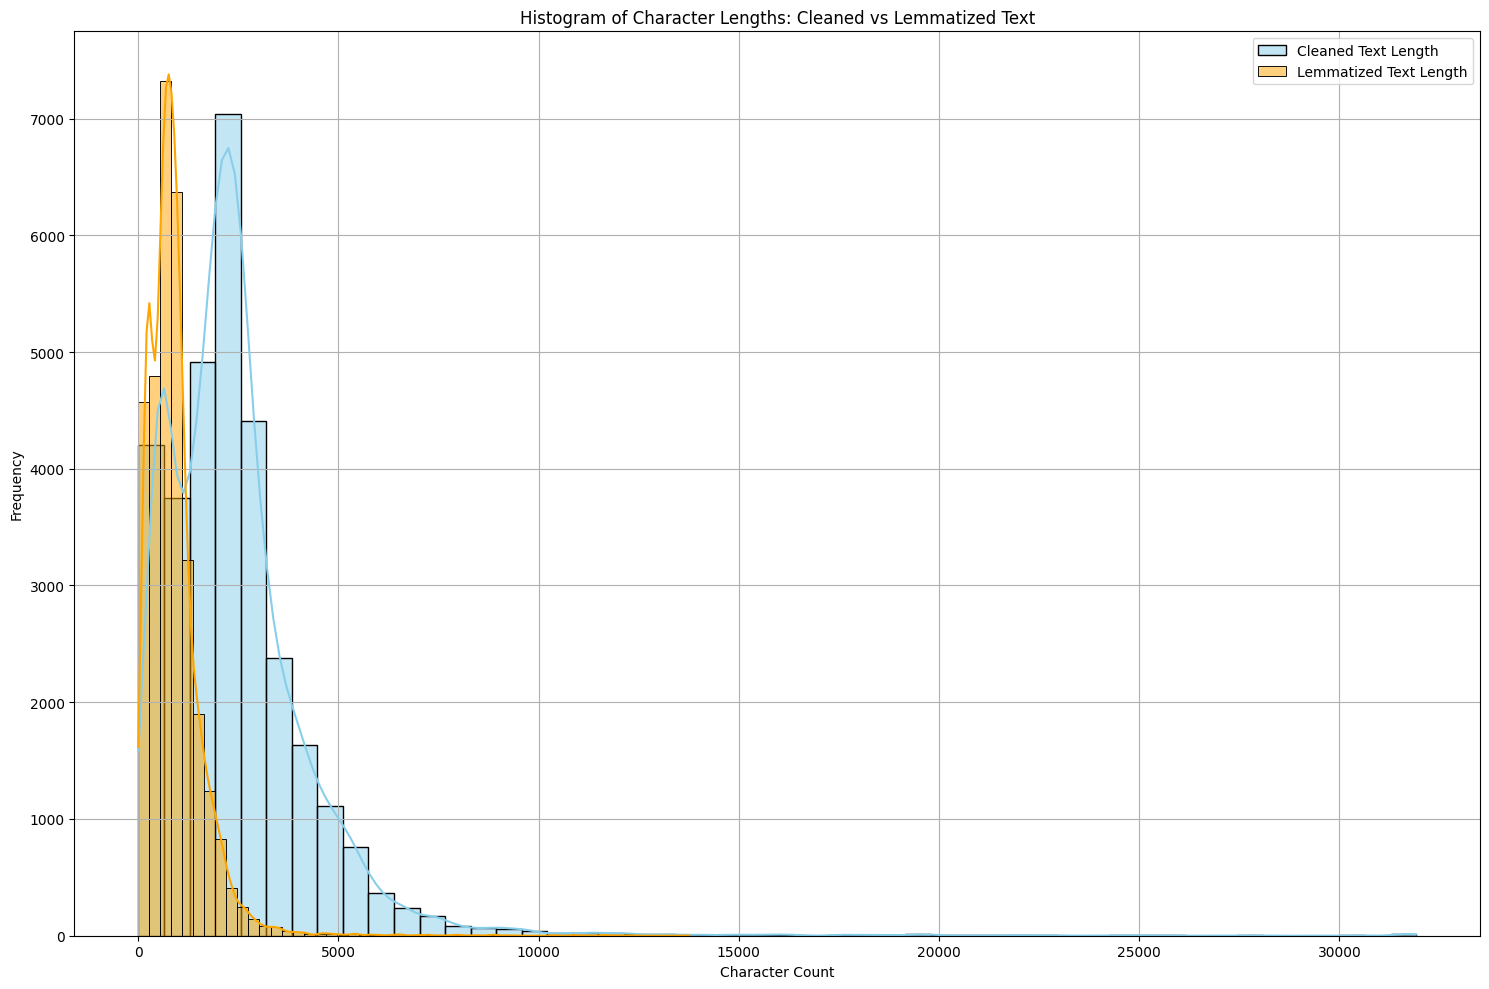

In [69]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(15, 10))

# Add histogram for cleaned news text
sns.histplot(X_train['cleaned_text_len'], bins=50, color='skyblue', label='Cleaned Text Length', kde=True)

# Add histogram for lemmatized news text with POS tags removed
sns.histplot(X_train['lemmatized_text_len'], bins=50, color='orange', label='Lemmatized Text Length', kde=True)

# Final plot details
plt.title('Histogram of Character Lengths: Cleaned vs Lemmatized Text')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

In [72]:
# Combine X_train and y_train into one DataFrame for filtering
train_data = X_train.copy()
train_data['news_label'] = y_train.values

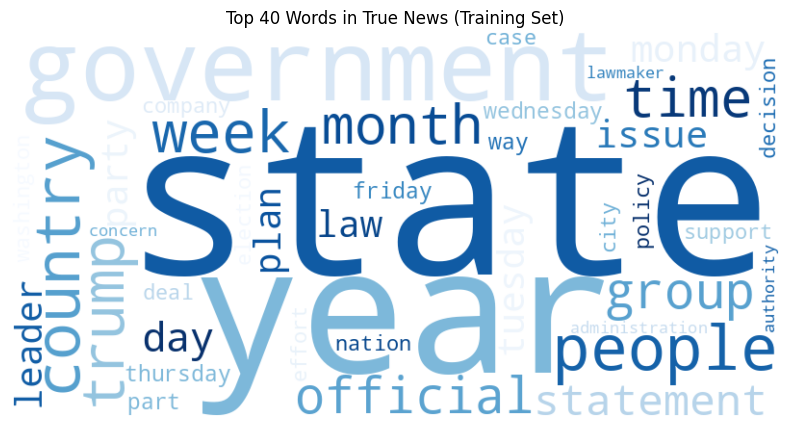

In [73]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text
# Filter news with label 1 (True News) and convert to it string and handle any non-string values
true_news_text = ' '.join(train_data[train_data['news_label'] == 1]['lemmatized_text'].dropna().astype(str))

# Generate word cloud for True News
wordcloud_true = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Blues').generate(true_news_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in True News (Training Set)')
plt.show()

**Observation:**
- The word cloud clearly highlights the most frequent words in true news articles within the training dataset after lemmatization.

- Key observations include:
    - Dominant terms like "state," "government," and "year" suggest a focus on official affairs, political structures, and temporal aspects.
    - Words such as "time," "day," "week," and "month" further reinforce the temporal nature of news reporting.
    - Terms like "people," "country," "group," "official," "leader," and "company" indicate a focus on entities and actors involved in news events.
    - Specific terms like "trump" also appear, suggesting coverage of particular individuals or political figures.
    - Common news-related vocabulary like "statement," "plan," "deal," and "policy" are prominent, indicating the subject matter often revolves around announcements, strategies, agreements, and regulations.
    - Days of the week ("monday," "friday," "thursday," "wednesday," "tuesday") are frequently mentioned, which is expected in news articles that often report on events occurring on specific days.

    - Overall, the word cloud provides valuable insight into the typical vocabulary and thematic content of true news stories in this dataset, which appears to be heavily centered around governmental, political, and daily temporal events.

##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

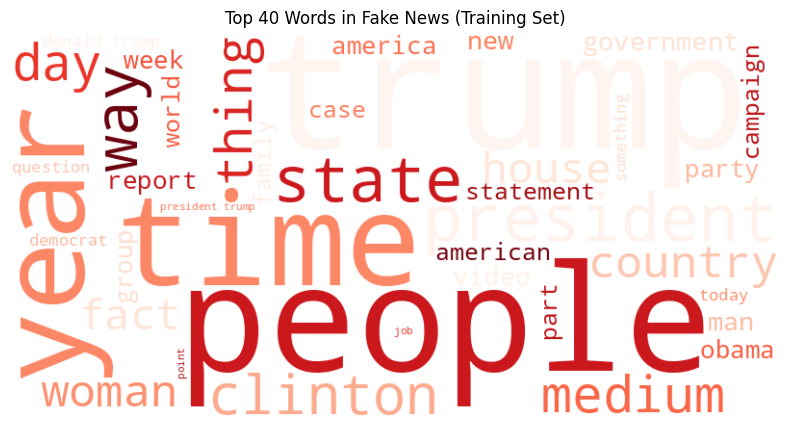

In [76]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
fake_news_text = ' '.join(train_data[train_data['news_label'] == 0]['lemmatized_text'].dropna().astype(str))

# Generate word cloud for Fake News
wordcloud_fake = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Reds').generate(fake_news_text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in Fake News (Training Set)')
plt.show()

**Observation:**
- This word cloud showcases the top 40 most frequent words found in fake news articles within the training dataset, after text processing.

- Key observations include:
     - The most striking feature is the overwhelming prominence of "trump," which is significantly larger than any other word, suggesting a strong focus on this individual in fake news narratives.
     - Other notable names like "clinton" and "obama" also appear, though much smaller, indicating that fake news often revolves around specific political figures.
     - Words like "people," "time," "year," "day," and "country" are also quite frequent, indicating a general news-like structure, but the context is likely skewed or exaggerated.
     - Terms such as "government," "state," "house," "president," and "american" suggest a continued engagement with political and national themes.
     - Interestingly, words like "fact," "report," "thing," "case," and "question" appear, which might be used in fake news to lend an air of legitimacy or to frame speculative content.
     - Terms like "video," "family," and "campaign" hint at the diverse topics and methods used in fake news dissemination.

 - In summary, the word cloud for fake news distinctively highlights a heavy emphasis on "trump" and other political figures, alongside general news vocabulary, but likely used in a misleading or sensationalized context, differentiating its thematic focus from true news.

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [80]:
# Write a function to get the specified top n-grams
# Function to extract top N n-grams from a given text corpus
def get_top_ngrams(corpus, ngram_range=(1, 1), n=None):
    # Create a CountVectorizer to extract n-gram frequencies, ignoring English stopwords
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    
    # Transform the corpus into a bag-of-words representation
    bag_of_words = vec.transform(corpus)
    
    # Sum the frequencies of each n-gram across all documents
    sum_words = bag_of_words.sum(axis=0) 
    
    # Create a list of (ngram, frequency) tuples
    word_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    
    # Sort the n-grams by frequency in descending order
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)
    
    # Return the top n n-grams as a DataFrame
    return pd.DataFrame(word_freq[:n], columns=['ngram', 'frequency'])

##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [82]:
# Handle NaN values in the text data
# Replace NaN with empty string in lemmatized_text column
train_data['lemmatized_text'] = train_data['lemmatized_text'].fillna('')

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

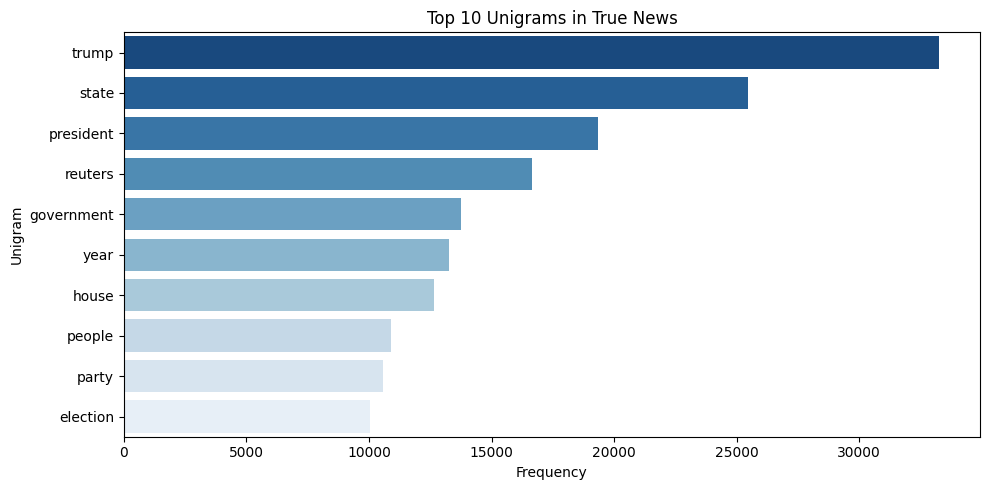

In [85]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
# Filter true news
true_news = train_data[y_train == 1]['lemmatized_text']

# Get top 10 unigrams
top_unigrams_true = get_top_ngrams(true_news, ngram_range=(1,1), n=10)

# Plot the bar graph
plt.figure(figsize=(10, 5))
sns.barplot(data=top_unigrams_true, x='frequency', y='ngram', palette='Blues_r')
plt.title('Top 10 Unigrams in True News')
plt.xlabel('Frequency')
plt.ylabel('Unigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 unigrams (single words) by frequency in true news articles.

- Key observations include:

    - "trump" is by far the most frequent unigram, indicating a significant focus on this individual in true news reporting.
    - "state," "president," and "government" are also very high in frequency, reinforcing the emphasis on political and governmental topics.
    - "reuters" appearing as a top unigram suggests that Reuters news agency is a prominent source or is frequently mentioned within the true news articles.
    - Other frequent terms like "year," "house," "people," "party," and "election" further highlight the common themes of true news, which revolve around temporal aspects, political bodies, and general societal engagement.

- In summary, the unigram analysis of true news clearly points to a strong concentration on political figures and institutions, with "trump" being a central figure, and "reuters" identified as a significant entity within the dataset.

##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



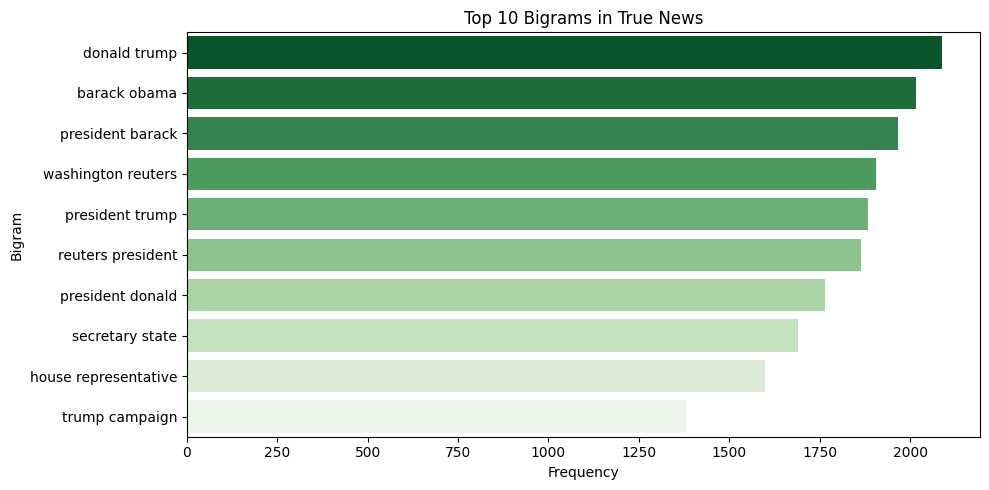

In [88]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
# Get top 10 bigrams
top_bigrams_true = get_top_ngrams(true_news, ngram_range=(2,2), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_bigrams_true, x='frequency', y='ngram', palette='Greens_r')
plt.title('Top 10 Bigrams in True News')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot presents the top 10 most frequent bigrams in true news.

- Key observations include:

    - "donald trump" is the most dominant bigram, underscoring his extensive coverage.
    - Other presidential bigrams like "barack obama," "president barack," "president trump," and "president donald" are highly frequent, highlighting a strong focus on political leaders.
    - "washington reuters" and "reuters president" suggest Reuters' prominence as a news source or subject.
    - "secretary state" and "house representative" indicate frequent mentions of specific government roles.
    - "trump campaign" points to coverage of political campaigns.
- In summary, true news bigrams are heavily concentrated on political figures, particularly presidents, and their associated activities, along with references to news sources and governmental roles.

##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



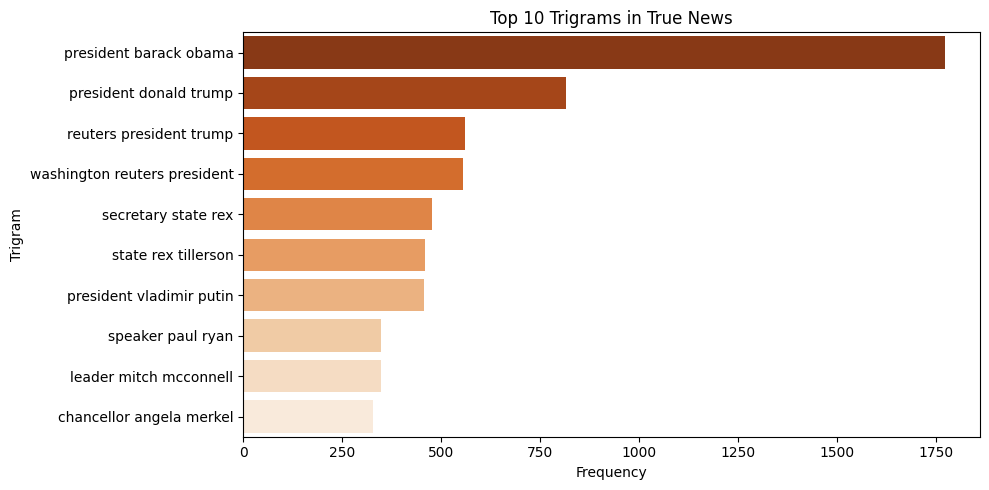

In [91]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
# Get top 10 trigrams
top_trigrams_true = get_top_ngrams(true_news, ngram_range=(3,3), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_trigrams_true, x='frequency', y='ngram', palette='Oranges_r')
plt.title('Top 10 Trigrams in True News')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot presents the top 10 most frequent trigrams in true news.

- Key observations include:

    - "president barack obama" and "president donald trump" are most frequent, highlighting a strong focus on full presidential names.
    - "reuters president trump" and "washington reuters president" show Reuters' involvement in presidential news.
    - "secretary state rex" and "state rex tillerson" point to specific official mentions.
    - "president vladimir putin," "speaker paul ryan," "leader mitch mcconnell," and "chancellor angela merkel" indicate coverage of other significant political leaders.
- In summary, true news trigrams heavily feature full names and titles of prominent political figures, domestic and international, alongside Reuters' role in presidential and governmental reporting.

### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

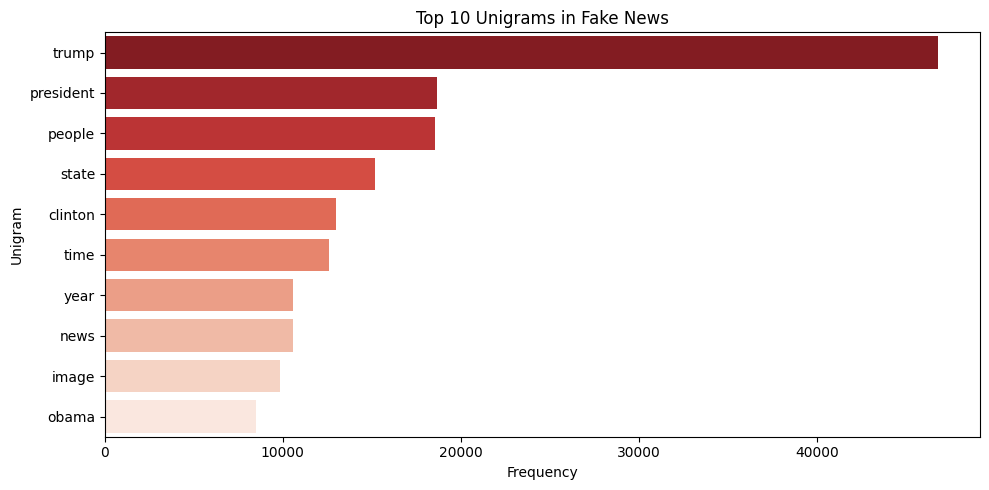

In [95]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
# Filter fake news
fake_news = train_data[y_train == 0]['lemmatized_text']

# Get top 10 unigrams
top_unigrams_fake = get_top_ngrams(fake_news, ngram_range=(1, 1), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_unigrams_fake, x='frequency', y='ngram', palette='Reds_r')
plt.title('Top 10 Unigrams in Fake News')
plt.xlabel('Frequency')
plt.ylabel('Unigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot presents the top 10 most frequent unigrams in fake news.

- Key observations include:
    - "trump" is very highly dominant, indicating a central focus.
    - "president," "people," and "state" are frequent, suggesting political and general societal discussion.
    - "clinton" and "obama" also appear, though less frequently than "trump."
    - "time," "year," and "news" are common terms, mimicking legitimate news.
    - "image" is notable, possibly suggesting visual content discussions.
- In summary, fake news unigrams heavily focus on "trump," other political figures, and general news terms, with "image" being a distinct inclusion.

##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



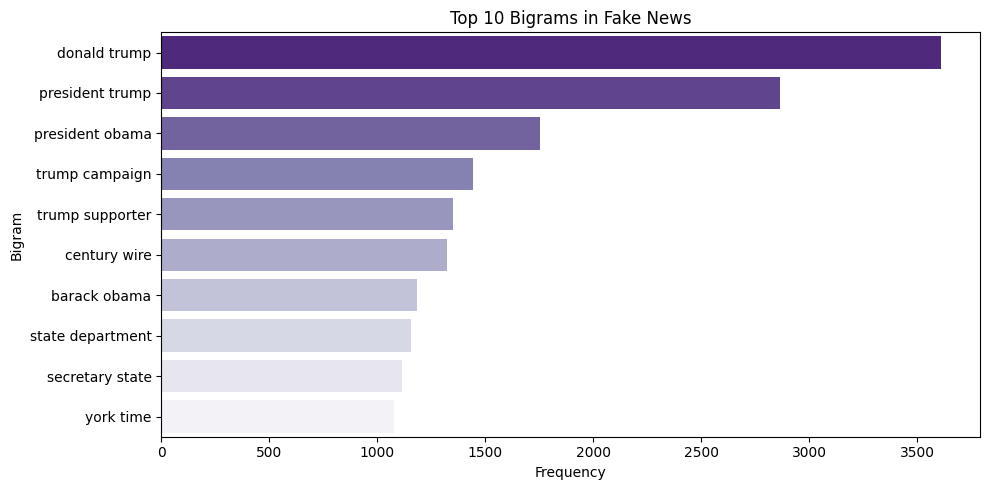

In [98]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
# Get top 10 bigrams
top_bigrams_fake = get_top_ngrams(fake_news, ngram_range=(2, 2), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_bigrams_fake, x='frequency', y='ngram', palette='Purples_r')
plt.title('Top 10 Bigrams in Fake News')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 most frequent bigrams in fake news.

- Key observations include:

    - "donald trump" is the most dominant bigram, significantly surpassing others, strengthening the strong focus on this individual.
    - "president trump" and "president obama" are also prominent, indicating a clear emphasis on presidential figures.
    - "trump campaign" and "trump supporter" highlight narratives specifically related to Trump's political activities and his base.
    - "century wire" suggests a particular source or entity frequently mentioned in fake news.
    - "barack obama" also appears, indicating continued discussion of the former president.
    - "state department" and "secretary state" point to governmental and official mentions.
    - "york time" could be a misspell or a specific reference often occurring in fake news.
- In summary, fake news bigrams are heavily centered around "donald trump" and other presidential figures, with specific mentions of Trump's campaign and supporters, along with references to certain news sources or entities and government departments.

##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



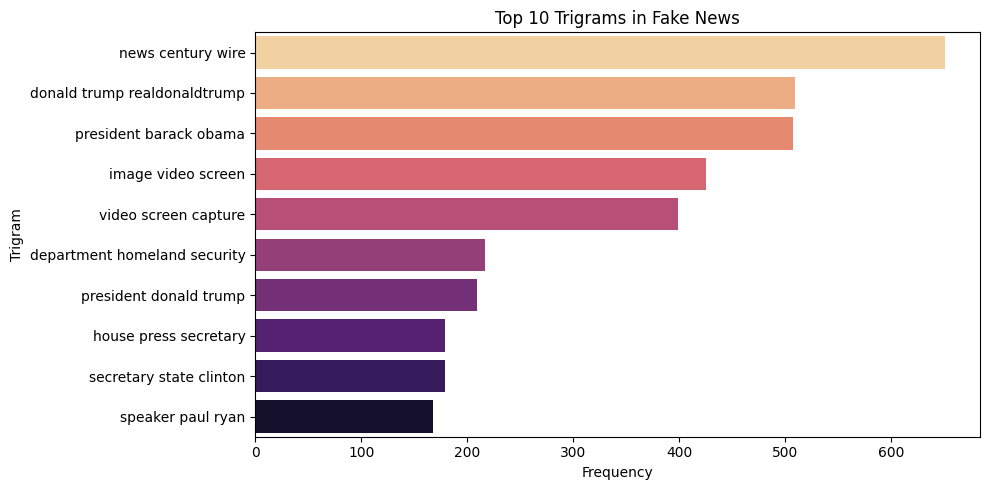

In [101]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
# Get top 10 trigrams
top_trigrams_fake = get_top_ngrams(fake_news, ngram_range=(3, 3), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_trigrams_fake, x='frequency', y='ngram', palette='magma_r')
plt.title('Top 10 Trigrams in Fake News')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 most frequent trigrams in fake news.

- Key observations include:
    - "news century wire" is the most frequent trigram, indicating a prominent source or phrase in fake news content.
    - "donald trump realdonaldtrump" suggests the direct use of social media handles or a specific emphasis on Trump's online presence in fake news.
    - "president barack obama" and "president donald trump" show a continued focus on presidential figures.
    - "image video screen" and "video screen capture" are notable, suggesting that fake news often involves or discusses visual media, possibly to fabricate or misrepresent content.
    - "department homeland security," "house press secretary," "secretary state clinton," and "speaker paul ryan" point to frequent mentions of specific government entities, roles, and officials, potentially in critical or conspiratorial contexts.
    
- In summary, fake news trigrams reveal a strong emphasis on specific news sources ("news century wire"), unique online identifiers ("realdonaldtrump"), prominent political figures, and a notable focus on visual media and specific government departments and roles, suggesting a blend of political commentary and potentially manipulated content.

## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [106]:
# Add character length columns to the validation data
val_data = X_val.copy()

# Add a new column to calculate the character length of cleaned news text
val_data['cleaned_text_length'] = val_data['cleaned_text'].fillna("").apply(len)

# Add a new column to calculate the character length of lemmatized news text with POS tags removed
val_data['lemmatized_text_length'] = val_data['lemmatized_text'].fillna("").apply(len)

# Display first few rows to verify
val_data[['cleaned_text_length', 'lemmatized_text_length']].head()

,cleaned_text_length,lemmatized_text_length
42487,4842,1747
4135,451,229
1497,607,241
15208,3195,1097
41465,2710,999


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

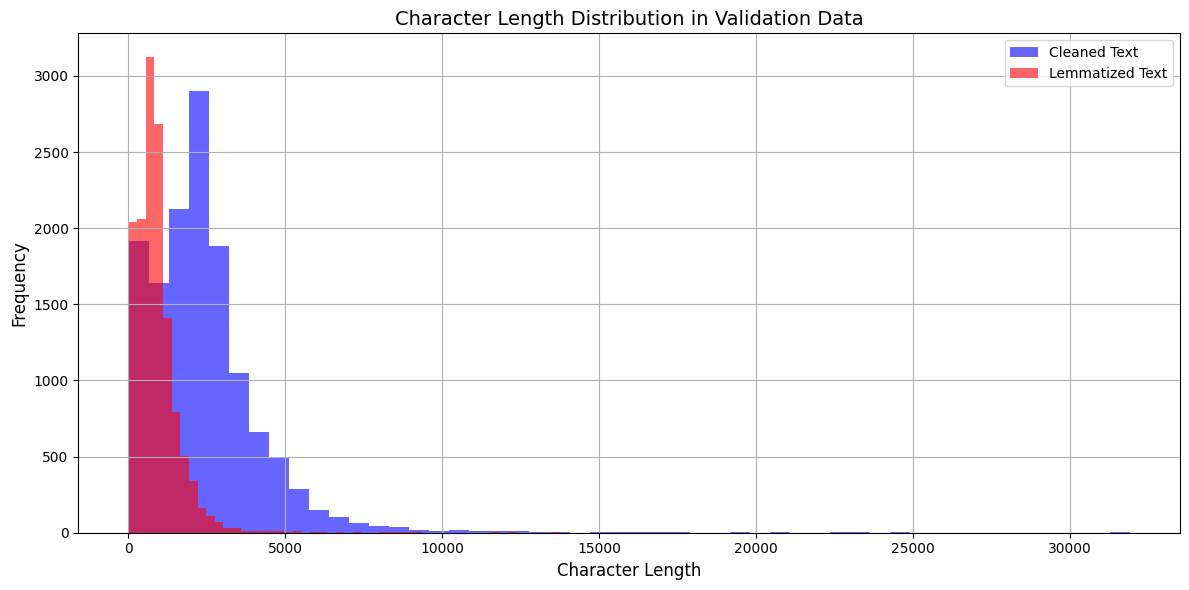

In [108]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(12, 6))
# Add histogram for cleaned news text
plt.hist(val_data['cleaned_text_length'], bins=50, color='blue', alpha=0.6, label='Cleaned Text')
# Add histogram for lemmatized news text with POS tags removed
plt.hist(val_data['lemmatized_text_length'], bins=50, color='red', alpha=0.6, label='Lemmatized Text')

# Titles and labels
plt.title("Character Length Distribution in Validation Data", fontsize=14)
plt.xlabel("Character Length", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation:**

- This histogram shows the character length distribution for "Cleaned Text" and "Lemmatized Text" in the validation data.

- Key observations include:
    - Both distributions are right-skewed.
    - "Lemmatized Text" is significantly shorter, peaking around 500 characters, indicating effective length reduction by lemmatization.
    - "Cleaned Text" has a broader, longer distribution, peaking between 1500-2500 characters.
    - There is overlap, but lemmatization clearly condenses texts to shorter lengths.
    
- In summary, the histogram demonstrates that lemmatization substantially reduces text character length, shifting the distribution to the left.

### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

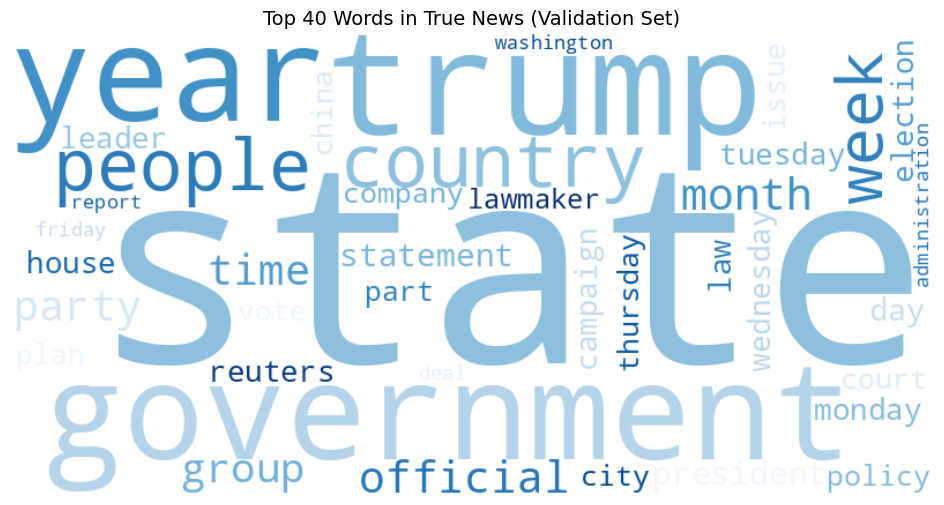

In [112]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text
# Generate word cloud for True News
# Filter only true news (label = 1)
true_val_text = val_data[y_val == 1]['lemmatized_text'].dropna().astype(str)

# Join all true news text
true_text_combined = ' '.join(true_val_text)

# Generate word cloud
wordcloud_true = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Blues').generate(true_text_combined)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in True News (Validation Set)", fontsize=14)
plt.show()

**Observation:**

- This word cloud displays the top 40 most frequent words in true news articles from the validation set.

- Key observations include:
    - "trump," "state," and "government" are the largest and most prominent words, indicating a strong focus on political figures and governmental affairs.
    - Terms like "time," "year," "month," "week," "day," and specific days of the week ("tuesday," "wednesday," "thursday," "friday," "monday") are highly visible, suggesting a strong temporal element in true news reporting.
    - Words such as "people," "country," "party," "group," "leader," "president," and "official" highlight the focus on political entities and individuals.
    - "reuters" is present, suggesting its continued relevance as a source or topic within true news.
    - Other terms like "house," "law," "vote," "election," "policy," "deal," "campaign," and "statement" reflect the common themes of political and legislative news.
      
- In summary, the word cloud for true news in the validation set reinforces a consistent emphasis on political figures (especially "trump"), governmental bodies, temporal aspects, and general political discourse, similar to the training set.

##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

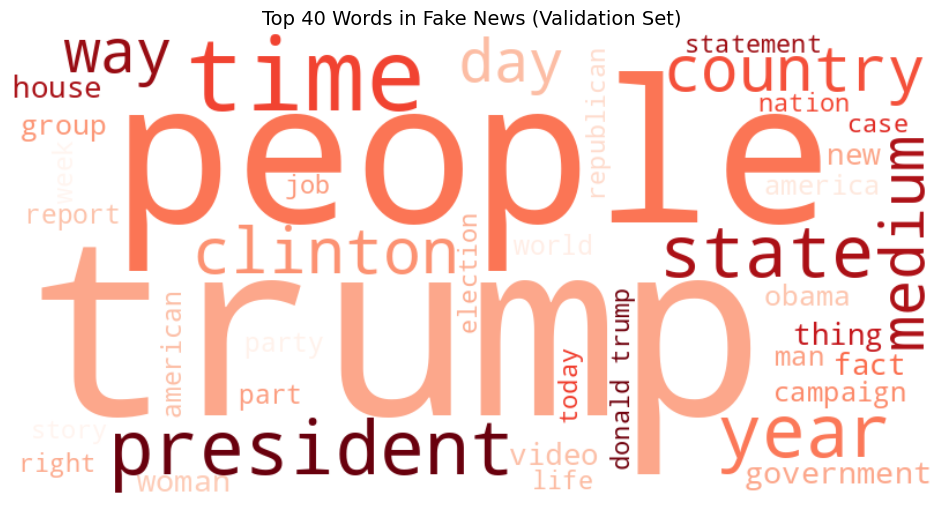

In [115]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Generate word cloud for Fake News
# Filter only fake news (label = 0)
fake_val_text = val_data[y_val == 0]['lemmatized_text'].dropna().astype(str)

# Join all fake news text
fake_text_combined = ' '.join(fake_val_text)

# Generate word cloud
wordcloud_fake = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Reds').generate(fake_text_combined)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in Fake News (Validation Set)", fontsize=14)
plt.show()

**Observation:**

- This word cloud displays the top 40 most frequent words in fake news articles from the validation set.

- Key observations include:
    - "trump" is overwhelmingly the largest word, demonstrating an extremely strong and consistent focus on this individual in fake news.
    - "people" and "time" are also very prominent, reflecting general conversational and temporal elements often found in sensationalized content.
    - "president," "clinton," and "obama" appear, indicating that other political figures are also central to fake news narratives, though less so than "trump."
    - Words like "country," "world," "state," and "government" suggest a global and national scope, often framed within a specific political agenda.
    - Terms such as "video," "image," "report," "fact," and "story" might be used to present or refer to potentially misleading or fabricated content.
    - "campaign," "group," "republican," "man," and "woman" indicate a focus on political movements, demographics, and gender.
      
- In summary, the word cloud for fake news in the validation set confirms an intense concentration on "trump," alongside other political figures, general terms, and specific words that hint at the manipulative or sensational nature of the content, consistent with observations from the training set.

### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [119]:
## Write a function to get the specified top n-grams
# Function to get the top n most frequent n-grams from a given corpus
def get_top_ngrams(corpus, ngram_range=(1, 1), n=None):
    # Initialize CountVectorizer with the specified n-gram range and English stopwords
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)

    # Transform the corpus into a bag-of-words representation
    bag_of_words = vec.transform(corpus)

    # Calculate the total frequency for each n-gram
    sum_words = bag_of_words.sum(axis=0)

    # Create a list of (ngram, frequency) tuples
    word_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    # Sort the n-grams by frequency in descending order
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)

    # Return the top n n-grams as a DataFrame
    return pd.DataFrame(word_freq[:n], columns=['ngram', 'frequency'])

##### 5.3.2 Handle the NaN values

In [121]:
## First handle NaN values in the text data
val_data['lemmatized_text'] = val_data['lemmatized_text'].fillna('')

### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

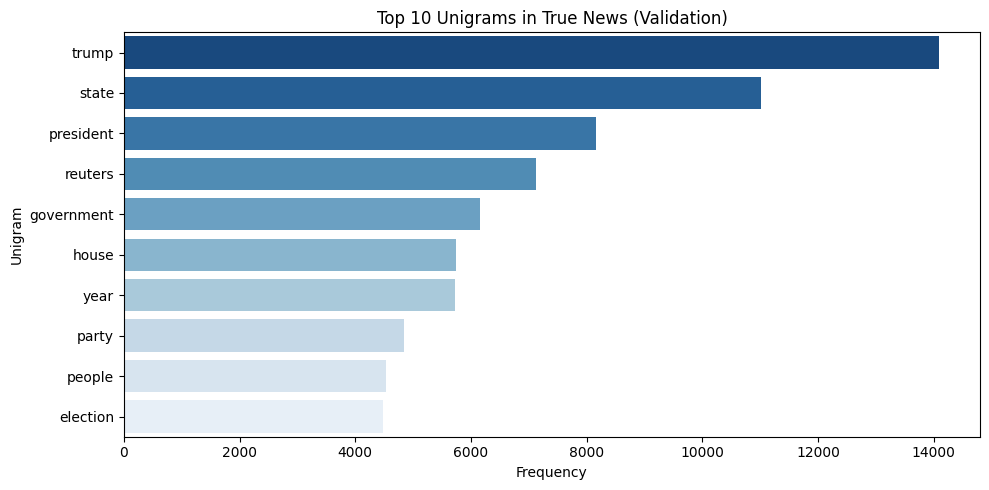

In [124]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
# Filter true news from validation set
true_news_val = val_data[y_val == 1]['lemmatized_text']

# Get top 10 unigrams
top_unigrams_true_val = get_top_ngrams(true_news_val, ngram_range=(1, 1), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_unigrams_true_val, x='frequency', y='ngram', palette='Blues_r')
plt.title('Top 10 Unigrams in True News (Validation)')
plt.xlabel('Frequency')
plt.ylabel('Unigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 unigrams by frequency in true news articles from the validation set.

- Key observations include:
    - "trump" is the most frequent unigram, consistently appearing as a central figure in true news.
    - "state," "president," and "government" are also highly frequent, reinforcing the strong emphasis on political leadership and governmental affairs.
    - "reuters" is a prominent unigram, indicating its continued significance as a news source or subject within true news.
    - Other terms like "house," "year," "party," "people," and "election" are frequently mentioned, reflecting common themes in political and societal news.
      
- In summary, the unigram analysis of true news in the validation set confirms a consistent focus on "trump," political institutions and figures, and the recurring presence of "reuters," aligning with observations from the training data.

##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

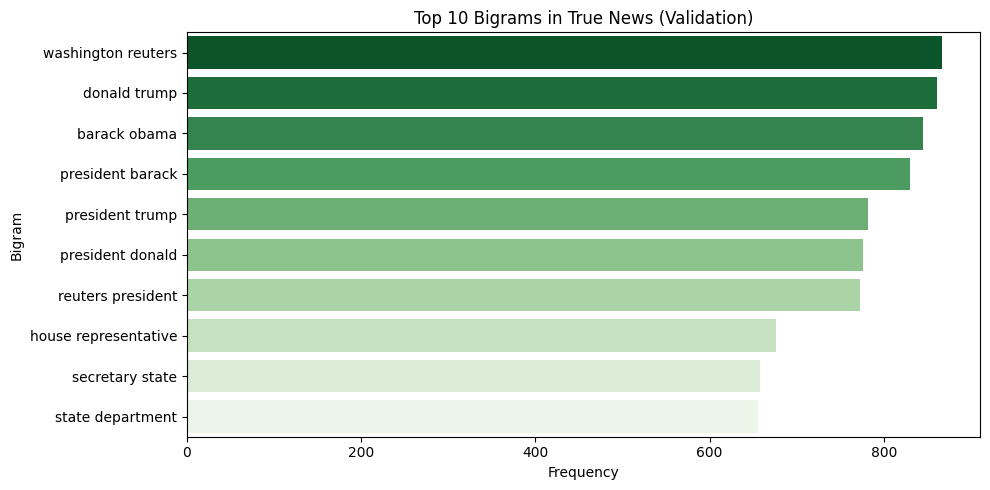

In [127]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
# Get top 10 bigrams
top_bigrams_true_val = get_top_ngrams(true_news_val, ngram_range=(2, 2), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_bigrams_true_val, x='frequency', y='ngram', palette='Greens_r')
plt.title('Top 10 Bigrams in True News (Validation)')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 most frequent bigrams in true news articles from the validation set.

- Key observations include:
    - "washington reuters" is the most frequent bigram, indicating a strong connection between Reuters and news originating from Washington D.C.
    - "donald trump," "barack obama," "president barack," "president trump," and "president donald" are highly prominent, reinforcing the focus on presidential figures by their full names or titles.
    - "reuters president" further highlights the association of Reuters with presidential reporting.
    - "house representative," "secretary state," and "state department" indicate frequent mentions of specific governmental roles and entities.
    
- In summary, the bigram analysis of true news in the validation set consistently shows a heavy emphasis on prominent political figures (especially presidents), the significant role of Reuters in reporting on Washington and presidential affairs, and mentions of key governmental positions.

##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

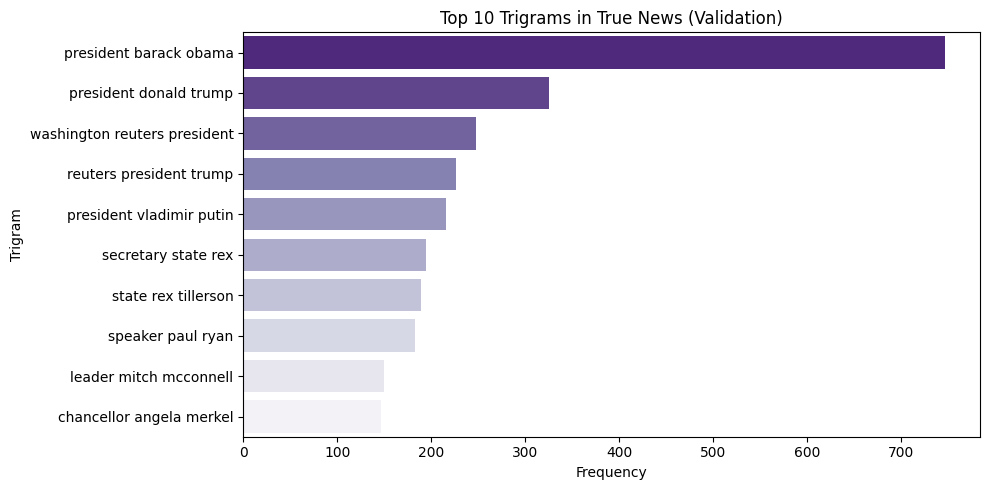

In [130]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
# Get top 10 trigrams
top_trigrams_true_val = get_top_ngrams(true_news_val, ngram_range=(3, 3), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_trigrams_true_val, x='frequency', y='ngram', palette='Purples_r')
plt.title('Top 10 Trigrams in True News (Validation)')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 most frequent trigrams in true news articles from the validation set.

- Key observations include:
    - "president barack obama" is the most frequent trigram, followed closely by "president donald trump," indicating a strong focus on full names and titles of prominent presidents.
    - "washington reuters president" and "reuters president trump" reinforce the significant connection between Reuters, Washington, and presidential news.
    - "president vladimir putin" highlights coverage of international leaders.
    - "secretary state rex" and "state rex tillerson" point to specific mentions of government officials and their titles (e.g., Rex Tillerson as Secretary of State).
    - "speaker paul ryan," "leader mitch mcconnell," and "chancellor angela merkel" indicate frequent mentions of other key political figures, both domestic and international.
  
- In summary, the trigram analysis of true news in the validation set consistently shows a primary focus on the full names and titles of influential political figures (both US and international), and the notable role of Reuters in reporting on presidential and governmental matters.

### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

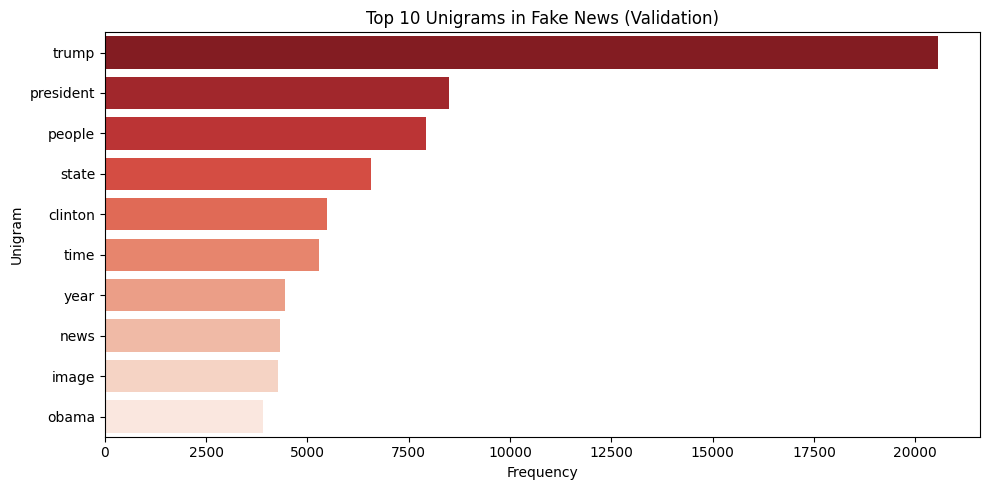

In [134]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
# Filter fake news from validation set
fake_news_val = val_data[y_val == 0]['lemmatized_text']

# Get top 10 unigrams
top_unigrams_fake_val = get_top_ngrams(fake_news_val, ngram_range=(1, 1), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_unigrams_fake_val, x='frequency', y='ngram', palette='Reds_r')
plt.title('Top 10 Unigrams in Fake News (Validation)')
plt.xlabel('Frequency')
plt.ylabel('Unigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 unigrams by frequency in fake news articles from the validation set.

- Key observations include:
    - "trump" is overwhelmingly the most frequent unigram, demonstrating a consistent and dominant focus on this individual in fake news narratives.
    - "president," "people," and "state" are also highly frequent, indicating that fake news often discusses political roles, the general populace, and governmental entities.
    - "clinton" and "obama" appear among the top unigrams, though less frequently than "trump," confirming their continued presence as subjects in fake news.
    - "time," "year," and "news" are common general terms, but their appearance here highlights how fake news mimics the structure and vocabulary of legitimate news.
    - The inclusion of "image" is notable, potentially suggesting that visual content or discussions about images are a significant component of fake news.
  
- In summary, the unigram analysis of fake news in the validation set reveals an extreme concentration on "trump," along with other political figures and general news-related terms, with "image" being a distinct term that could point to the use or discussion of visual media in fake news content.

##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

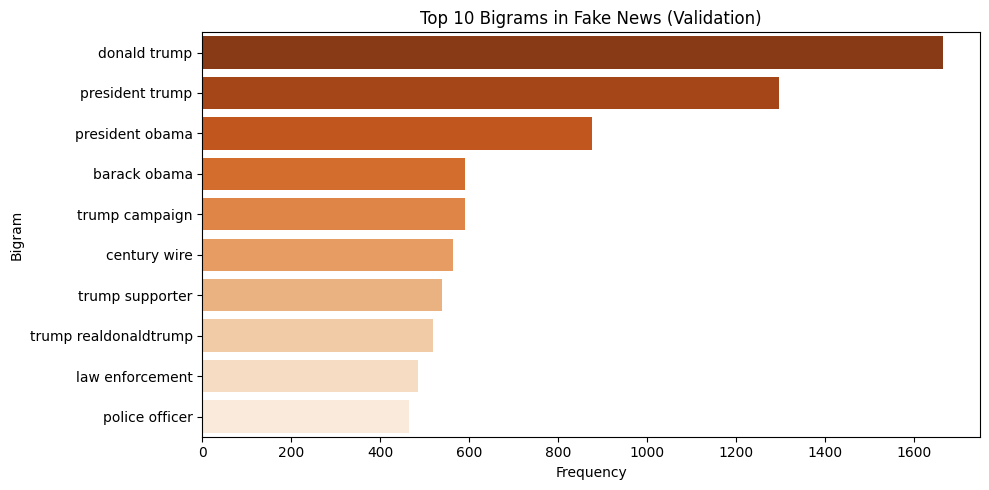

In [137]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
# Get top 10 bigrams
top_bigrams_fake_val = get_top_ngrams(fake_news_val, ngram_range=(2, 2), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_bigrams_fake_val, x='frequency', y='ngram', palette='Oranges_r')
plt.title('Top 10 Bigrams in Fake News (Validation)')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 most frequent bigrams in fake news articles from the validation set.

- Key observations include:
    - "donald trump" is overwhelmingly the most dominant bigram, significantly more frequent than others, reinforcing the extreme focus on this individual in fake news.
    - "president trump" and "president obama" are also very prominent, indicating a strong emphasis on presidential figures.
    - "barack obama" also appears, continuing the discussion of former presidents.
    - "trump campaign," "century wire," and "trump supporter" highlight specific narratives related to Trump's political activities, a particular source, and his base.
    - "trump realdonaldtrump" is notable, suggesting the use of social media handles or a focus on Trump's online presence.
    - "law enforcement" and "police officer" indicate frequent mentions related to legal and law enforcement themes, which could be part of specific fake news narratives.
      
- In summary, fake news bigrams in the validation set are highly concentrated around "donald trump" and other presidential figures, with strong emphasis on Trump's political activities and online presence, alongside mentions of specific sources and law enforcement topics.

##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

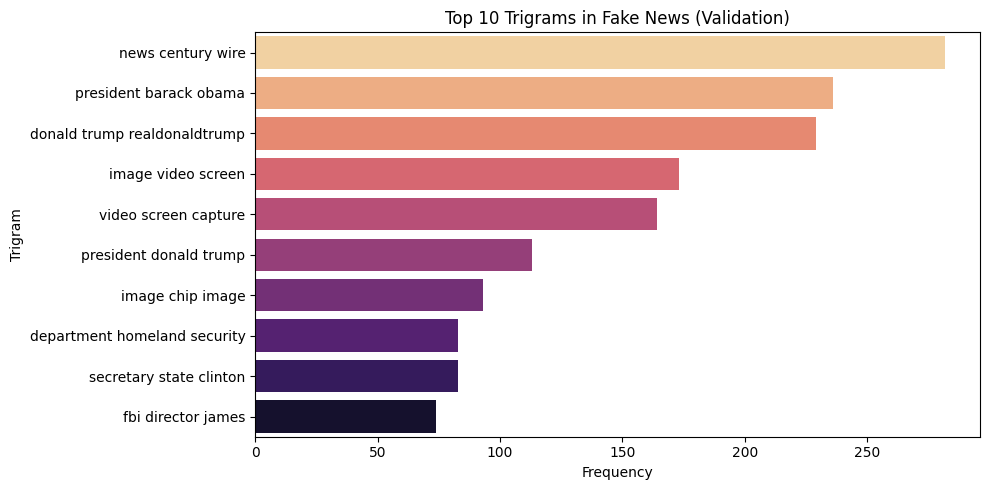

In [140]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
# Get top 10 trigrams
top_trigrams_fake_val = get_top_ngrams(fake_news_val, ngram_range=(3, 3), n=10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_trigrams_fake_val, x='frequency', y='ngram', palette='magma_r')
plt.title('Top 10 Trigrams in Fake News (Validation)')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()

**Observation:**

- This bar plot displays the top 10 most frequent trigrams in fake news articles from the validation set.

- Key observations include:
    - "news century wire" is the most frequent trigram, indicating a prominent source or phrase consistently appearing in fake news.
    - "president barack obama" and "donald trump realdonaldtrump" are highly prominent, highlighting the focus on full names of political figures and the specific mention of Trump's social media handle.
    - "image video screen" and "video screen capture" are notable, suggesting that discussions about visual media, possibly manipulated, are common in fake news.
    - "president donald trump" is also present, further emphasizing his centrality.
    - "image chip image" is a peculiar trigram, potentially related to discussions about digital imagery or technology in fake news.
    - "department homeland security," "secretary state clinton," and "fbi director james" indicate frequent mentions of specific government entities, roles, and officials (e.g., James Comey as FBI Director).
    
- In summary, fake news trigrams in the validation set show a strong emphasis on specific news sources, political figures (with a unique focus on Trump's online presence), and a notable recurring theme around visual media, alongside mentions of key government departments and officials.

## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [144]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
import gensim.downloader as api
# Download and load the Word2Vec Google News 300-dimensional model
word2vec_model = api.load("word2vec-google-news-300")

# Check how many word vectors are loaded
print(f"Word2Vec model loaded with {len(word2vec_model.key_to_index)} words.")

Word2Vec model loaded with 3000000 words.


### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [146]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data
# Function to compute average Word2Vec embeddings for a text
def get_average_word2vec(tokens_list, model, vector_size=300):
    vecs = []
    
    # Loop through each token and collect its vector if it exists in the model
    for token in tokens_list:
        if token in model:
            vecs.append(model[token])
    
    # If none of the tokens are in the model, return a zero vector
    if len(vecs) == 0:
        return np.zeros(vector_size)
    else:
        # Otherwise, return the mean of the collected vectors
        return np.mean(vecs, axis=0)

# Drop NaNs (if any) just in case
X_train['lemmatized_text'] = X_train['lemmatized_text'].fillna('')
X_val['lemmatized_text'] = X_val['lemmatized_text'].fillna('')

# Tokenize the lemmatized text
X_train_tokens = X_train['lemmatized_text'].apply(lambda x: x.split())
X_val_tokens = X_val['lemmatized_text'].apply(lambda x: x.split())

# Compute average Word2Vec vectors
X_train_vec = np.array([get_average_word2vec(tokens, word2vec_model) for tokens in X_train_tokens])
X_val_vec = np.array([get_average_word2vec(tokens, word2vec_model) for tokens in X_val_tokens])

## Extract the target variable for the training data and validation data
y_train_vec = y_train.values
y_val_vec = y_val.values

In [147]:
# Print shapes to confirm
print("X_train_vec shape:", X_train_vec.shape)
print("X_val_vec shape:", X_val_vec.shape)
print("y_train_vec shape:", y_train_vec.shape)
print("y_val_vec shape:", y_val_vec.shape)

X_train_vec shape: (31437, 300)
X_val_vec shape: (13473, 300)
y_train_vec shape: (31437,)
y_val_vec shape: (13473,)


## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [150]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [153]:
## Initialise Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=9)

## Train Logistic Regression model on training data
lr_model.fit(X_train_vec, y_train_vec)

## Predict on validation data
y_pred_lr = lr_model.predict(X_val_vec)

##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [155]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
# Calculate metrics
accuracy = accuracy_score(y_val_vec, y_pred_lr)
precision = precision_score(y_val_vec, y_pred_lr)
recall = recall_score(y_val_vec, y_pred_lr)
f1 = f1_score(y_val_vec, y_pred_lr)

# Print metrics
print("Logistic Regression Performance on Validation Data:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Logistic Regression Performance on Validation Data:
Accuracy : 0.9268
Precision: 0.9208
Recall   : 0.9262
F1-Score : 0.9235


In [156]:
# Classification Report
print("\nClassification Report for Logistic Regression model:")
print(classification_report(y_val_vec, y_pred_lr))


Classification Report for Logistic Regression model:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7048
           1       0.92      0.93      0.92      6425

    accuracy                           0.93     13473
   macro avg       0.93      0.93      0.93     13473
weighted avg       0.93      0.93      0.93     13473



**Observation:**

- The Logistic Regression model performs strongly on the validation data.

- Key observations include:

    - **Accuracy**: High at `0.9268`, indicating nearly `93%` correct predictions.
    - **Precision**: `0.9208` overall, with `0.93` for 'class 0' and `0.92` for 'class 1', showing high confidence in positive predictions.
    - **Recall**: `0.9262` overall, with `0.93` for both classes, indicating effective capture of actual instances.
    - **F1-Score**: `0.9235` overall, with `0.93` for 'class 0' and `0.92` for 'class 1', confirming a good balance between precision and recall.
    - **Support**: Balanced class distribution in the validation set (7048 for 'class 0', 6425 for 'class 1').
In summary, the Logistic Regression model is robust and reliable for distinguishing true and fake news, showing consistently high performance across all key metrics for both classes.

### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [160]:
## Initialise Decision Tree model
dt_model = DecisionTreeClassifier(random_state=9)

## Train Decision Tree model on training data
dt_model.fit(X_train_vec, y_train_vec)

## Predict on validation data
y_pred_dt = dt_model.predict(X_val_vec)

##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [162]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
# Calculate metrics
accuracy = accuracy_score(y_val_vec, y_pred_dt)
precision = precision_score(y_val_vec, y_pred_dt)
recall = recall_score(y_val_vec, y_pred_dt)
f1 = f1_score(y_val_vec, y_pred_dt)

# Print results
print("Decision Tree Performance on Validation Data:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Decision Tree Performance on Validation Data:
Accuracy : 0.8484
Precision: 0.8508
Recall   : 0.8272
F1-Score : 0.8389


In [163]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_val_vec, y_pred_dt))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      7048
           1       0.85      0.83      0.84      6425

    accuracy                           0.85     13473
   macro avg       0.85      0.85      0.85     13473
weighted avg       0.85      0.85      0.85     13473



**Observation:**

- The Decision Tree model exhibits moderate performance on the validation data.

- Key observations include:

    - **Accuracy**: At `0.8484`, it correctly predicts about `84.84%` of the samples.
    - **Precision**: Overall `0.8508`, with similar values for both classes (`0.85` for 'class 0', `0.85` for 'class 1'), indicating a fair rate of -correct positive predictions.
    - **Recall**: Overall `0.8272`, with `0.87` for class 0 and `0.83` for 'class 1', suggesting it is slightly better at identifying class 0 instances.
    - **F1-Score**: Overall `0.8389`, with `0.86` for class 0 and `0.84` for 'class 1', indicating a reasonable balance between precision and recall, but slightly lower than Logistic Regression.
    - **Support**: A balanced distribution of samples across classes (7048 for 'class 0', 6425 for 'class 1').
In summary, the Decision Tree model provides decent but not outstanding performance, with slightly lower metrics across the board compared to the Logistic Regression model, particularly in recall for 'class 1'.

### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [167]:
## Initialise Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=9)

## Train Random Forest model on training data
rf_model.fit(X_train_vec, y_train_vec)

## Predict on validation data
y_pred_rf = rf_model.predict(X_val_vec)

 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [169]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
# Calculate metrics
accuracy = accuracy_score(y_val_vec, y_pred_rf)
precision = precision_score(y_val_vec, y_pred_rf)
recall = recall_score(y_val_vec, y_pred_rf)
f1 = f1_score(y_val_vec, y_pred_rf)

# Print results
print("Random Forest Performance on Validation Data:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Random Forest Performance on Validation Data:
Accuracy : 0.9236
Precision: 0.9306
Recall   : 0.9074
F1-Score : 0.9188


In [170]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_val_vec, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7048
           1       0.93      0.91      0.92      6425

    accuracy                           0.92     13473
   macro avg       0.92      0.92      0.92     13473
weighted avg       0.92      0.92      0.92     13473



**Observation:**

- The Random Forest model shows strong performance on the validation data.

- Key observations include:

    - **Accuracy**: High at `0.9236`, indicating correct predictions for over `92%` of samples.
    - **Precision**: Overall `0.9306`, with `0.92` for 'class 0' and `0.93` for 'class 1', showing strong confidence in positive predictions for both.
    - **Recall**: Overall `0.9074`, with `0.94` for 'class 0' and `0.91` for 'class 1', suggesting it's slightly better at identifying class 0.
    - **F1-Score**: Overall `0.9188`, with `0.93` for 'class 0' and `0.92` for 'class 1', indicating a good balance between precision and recall, especially strong for class 0.
    - **Support**: Balanced class distribution (7048 for 'class 0', 6425 for 'class 1').
In summary, the Random Forest model is a strong performer, comparable to Logistic Regression, with high accuracy and well-balanced precision and recall across both classes, though slightly favoring recall for 'class 0'.

## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

In this project, we explored semantic classification for detecting fake news using a dataset composed of true and fake news articles. After thorough preprocessing, including stopword removal, lemmatization, and POS-tag filtering, we performed detailed exploratory data analysis (EDA) to understand the linguistic patterns in true and fake news content. The EDA revealed that fake news often contained shorter lemmatized text and had distinct high-frequency terms compared to true news, suggesting stylistic and lexical differences between the two classes.

To capture semantic relationships in the data, we used the **Word2Vec model** pretrained on Google News to convert the processed text into vector embeddings. This approach enabled the classifiers to understand contextual meaning beyond simple word counts.

We trained and evaluated three supervised machine learning models:
- **Logistic Regression**
- **Decision Tree**
- **Random Forest**

Among these, **Logistic Regression** performed the best on the validation set with:
- **Accuracy:** 92.68%
- **Precision:** 92.08%
- **Recall:** 92.62%
- **F1-Score:** 92.35%

These results suggest that **logistic regression**, despite its simplicity, is well-suited for binary classification in this case when paired with rich semantic features. It consistently outperformed the more complex decision tree and random forest models, likely due to its ability to generalize well with high-dimensional embeddings.

The metric prioritized in our evaluation was the **F1-score**, as it balances both precision and recall. This is crucial in fake news detection where both false positives and false negatives can have significant real-world consequences.

Overall, the semantic classification approach proved highly effective, and the use of Word2Vec embeddings greatly enhanced model performance. This workflow provides a scalable and interpretable solution for fake news detection in real-world applications.